# Compare orbit solutions — Bernese

Compares Bernese orbit solutions from `.OUT` files in the RTN frame.

Supported modes:
- `ZAZG` — STDDIF epoch-wise differences between `ZA` and `ZG` solutions.
- `ZA` / `ZG` — ORBGEN fit residuals for a single parametrisation.

Files are downloaded via SSH from the remote server and/or copied from a local folder.

## Imports

Load standard library modules, third-party packages, and the local `doris` package.

In [1]:
# --- Standard library ---
import re
import sys
from datetime import date, timedelta
from pathlib import Path

# --- Third-party packages ---
try:
    import numpy as np
except ImportError as e:
    raise RuntimeError("Missing dependency: 'numpy'. Install it with: pip install numpy") from e

try:
    import pandas as pd
    pd.set_option("display.float_format", "{:.5f}".format)
    pd.set_option("display.max_columns", 120)
except ImportError as e:
    raise RuntimeError("Missing dependency: 'pandas'. Install it with: pip install pandas") from e

try:
    import matplotlib.dates as mdates
    import matplotlib.pyplot as plt
except ImportError as e:
    raise RuntimeError("Missing dependency: 'matplotlib'. Install it with: pip install matplotlib") from e

# --- doris library ---
try:
    from doris.input.ssh import download_from_ssh
    from doris.input.local import copy_from_local
    from doris.analysis.spectral.periodogram import compute_periodogram
    from doris.output.tables import save_latex_table, Col
except ImportError as e:
    raise RuntimeError(
        "Missing doris modules. Make sure the project is installed with: pip install -e ."
    ) from e


## Paths and parameters

Set the satellite, solution mode, DOY range, SSH connection, and output locations.

In [2]:
# --- Solution and satellite ---
SOLUTION = "ZAZG"   # ZA, ZG, or ZAZG
SAT      = "SA"     # SA, S6, J3, or None for all

# --- Day-of-year range ---
DOY_FROM  = 1
DOY_TO    = 30

# --- ORBGEN iteration (used for ZA / ZG only) ---
ITERATION = 2

# --- SUM file (contains remote OUT paths) ---
SUM_PATH = Path(f"C:/Users/michal/Desktop/bernese/vysledky/cmorb_{SAT}_ZA_ZG_24_001_030.SUM")

# --- Project paths ---
PROJECT_ROOT = Path("../..").resolve()
DATA_ROOT    = PROJECT_ROOT / "data"

DOWNLOAD_DIR = DATA_ROOT / "bernese"
RESULTS_DIR  = DATA_ROOT / "results"

# --- SSH connection ---
SSH_HOST       = "amalie.pecny.cz"
SSH_PORT       = 22
SSH_USERNAME   = "mkovar"
SSH_LOGIN_FILE = Path("login_ssh.txt")

# Normalize
SOLUTION = SOLUTION.upper()
if SAT is not None:
    SAT = SAT.upper()

_sat_subdir = SAT.lower() if SAT else "all"
FIGURES_DIR = PROJECT_ROOT / "LaTeX" / "images" / "results" / "satellites" / "bernese" / _sat_subdir
TABLES_DIR  = PROJECT_ROOT / "LaTeX" / "tables" / "satellites" / "bernese" / _sat_subdir

DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

# Display labels for plots
_SAT_DISPLAY = {"CR": "CS2", "HC": "H2C", "HD": "H2D", "J3": "JA3",
                "AS": "S3A", "BS": "S3B", "S6": "S6A", "SA": "SRL"}
_SOL_DISPLAY = {"ZA": "SSA", "ZG": "GOP", "ZAZG": "GOP–SSA"}

_sat_display = _SAT_DISPLAY.get(SAT, SAT) if SAT else "všechny"
_sol_display = _SOL_DISPLAY.get(SOLUTION, SOLUTION)

print("SOLUTION    :", SOLUTION, "(", _sol_display, ")")
print("SAT         :", SAT, "(", _sat_display, ")")
print("DOY         :", DOY_FROM, "-", DOY_TO)
print("DOWNLOAD_DIR:", DOWNLOAD_DIR)
print("FIGURES_DIR :", FIGURES_DIR)
print("TABLES_DIR  :", TABLES_DIR)


SOLUTION    : ZAZG ( GOP–SSA )
SAT         : SA ( SRL )
DOY         : 1 - 30
DOWNLOAD_DIR: C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\data\bernese
FIGURES_DIR : C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\images\results\satellites\bernese\sa
TABLES_DIR  : C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\tables\satellites\bernese\sa


## SSH download

Detect the remote directory from the SUM file and download matching `.OUT` files.

In [3]:
# Detect remote directory from the SUM file.
_remote_re  = re.compile(r"(?P<remote>/\S+/)[A-Za-z0-9]+\d{3}0(?:ZAZG|ZA|ZG)\.OUT", re.I)
_remote_dir = None
if SUM_PATH.exists():
    _m = _remote_re.search(SUM_PATH.read_text(encoding="utf-8", errors="ignore"))
    if _m:
        _remote_dir = _m.group("remote").rstrip("/")

print("Remote dir from SUM:", _remote_dir)

_sat_glob = (SAT.lower() if SAT else "*")
_out_glob = f"{_sat_glob}*0{SOLUTION}.OUT"

if not _remote_dir:
    print("Remote directory not found in SUM file — SSH download skipped.")
else:
    result = download_from_ssh(
        host=SSH_HOST,
        port=SSH_PORT,
        username=SSH_USERNAME,
        remote_dir=_remote_dir,
        local_dir=DOWNLOAD_DIR,
        filename_pattern=_out_glob,
        login_file=SSH_LOGIN_FILE,
        overwrite=False,
        decompress=False,
        keep_compressed=True,
    )
    print(f"Downloaded: {result.count_downloaded}, skipped: {result.count_skipped_existing}")


Remote dir from SUM: /home/doris/GPSDATA/DORIS_B/OUT


Downloading:   0%|          | 0/30 [00:00<?, ?file/s]

Downloaded: 0, skipped: 30


## Local consolidation

Copy `.OUT` files from the SUM folder (and an optional fallback folder) into `DOWNLOAD_DIR`.

In [4]:
# Copy from the SUM folder if it differs from DOWNLOAD_DIR.
if SUM_PATH.parent.exists() and SUM_PATH.parent.resolve() != DOWNLOAD_DIR.resolve():
    r = copy_from_local(
        source_dir=SUM_PATH.parent,
        local_dir=DOWNLOAD_DIR,
        filename_pattern=_out_glob,
        overwrite=False,
        decompress=False,
    )
    print(f"SUM folder: copied {r.count_copied}, skipped {r.count_skipped_existing}")

# Optional fallback local folder.
_FALLBACK_DIR = None   # e.g. Path(r"C:\old\folder\downloaded_out")
if _FALLBACK_DIR and Path(_FALLBACK_DIR).exists():
    r = copy_from_local(
        source_dir=Path(_FALLBACK_DIR),
        local_dir=DOWNLOAD_DIR,
        filename_pattern=_out_glob,
        overwrite=False,
        decompress=False,
    )
    print(f"Fallback folder: copied {r.count_copied}, skipped {r.count_skipped_existing}")


Copying:   0%|          | 0/1 [00:00<?, ?file/s]

SUM folder: copied 0, skipped 1


## File discovery

List all `.OUT` files in `DOWNLOAD_DIR` that match the selected solution, satellite, and DOY range.

In [5]:
_out_name_re = re.compile(
    r"^(?P<sat>[A-Za-z0-9]+?)(?P<doy>\d{3})0(?P<solution>ZAZG|ZA|ZG)\.OUT$", re.I
)

rows = []
for path in DOWNLOAD_DIR.glob("*.OUT"):
    m = _out_name_re.match(path.name)
    if not m:
        continue
    sat      = m.group("sat").upper()
    doy      = int(m.group("doy"))
    solution = m.group("solution").upper()
    if solution != SOLUTION:
        continue
    if SAT is not None and sat != SAT:
        continue
    if not (DOY_FROM <= doy <= DOY_TO):
        continue
    rows.append({"sat": sat, "doy": doy, "solution": solution,
                 "file": path.name, "path": path,
                 "size_kb": path.stat().st_size / 1024})

files_df = (
    pd.DataFrame(rows, columns=["sat", "doy", "solution", "file", "path", "size_kb"])
    .sort_values(["sat", "doy", "file"])
    .reset_index(drop=True)
)

print(f"Files found: {len(files_df)}")
if not files_df.empty:
    display(files_df)


Files found: 30


,sat,doy,solution,file,path,size_kb
0,SA,1,ZAZG,SA0010ZAZG.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,24.82422
1,SA,2,ZAZG,SA0020ZAZG.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,24.82422
2,SA,3,ZAZG,SA0030ZAZG.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,24.82422
3,SA,4,ZAZG,SA0040ZAZG.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,24.82422
4,SA,5,ZAZG,SA0050ZAZG.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,24.82422
5,SA,6,ZAZG,SA0060ZAZG.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,24.82422
6,SA,7,ZAZG,SA0070ZAZG.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,24.82422
7,SA,8,ZAZG,SA0080ZAZG.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,24.82422
8,SA,9,ZAZG,SA0090ZAZG.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,24.82422
9,SA,10,ZAZG,SA0100ZAZG.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,24.82422


## Day coverage check

Verify that a file exists for every expected DOY in the range.

In [6]:
if SAT is None:
    print("SAT=None — coverage check skipped.")
else:
    expected = pd.DataFrame({
        "sat": SAT, "doy": range(DOY_FROM, DOY_TO + 1), "solution": SOLUTION,
    })
    coverage_df = expected.merge(
        files_df[["sat", "doy", "solution", "file", "path"]],
        on=["sat", "doy", "solution"], how="left",
    )
    coverage_df["found"] = coverage_df["file"].notna()
    print("Expected:", len(coverage_df))
    print("Found   :", int(coverage_df["found"].sum()))
    print("Missing :", int((~coverage_df["found"]).sum()))
    display(coverage_df)


Expected: 30
Found   : 30
Missing : 0


,sat,doy,solution,file,path,found
0,SA,1,ZAZG,SA0010ZAZG.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,True
1,SA,2,ZAZG,SA0020ZAZG.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,True
2,SA,3,ZAZG,SA0030ZAZG.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,True
3,SA,4,ZAZG,SA0040ZAZG.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,True
4,SA,5,ZAZG,SA0050ZAZG.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,True
5,SA,6,ZAZG,SA0060ZAZG.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,True
6,SA,7,ZAZG,SA0070ZAZG.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,True
7,SA,8,ZAZG,SA0080ZAZG.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,True
8,SA,9,ZAZG,SA0090ZAZG.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,True
9,SA,10,ZAZG,SA0100ZAZG.OUT,C:\Users\michal\Desktop\MasterThesis-DorisAnal...,True


## File parsers

- `parse_stddif_out` — parses STDDIF epoch-wise RTN differences from `ZAZG` files.
- `parse_orbgen_residuals` — parses ORBGEN epoch residuals from `ZA` / `ZG` files.

In [7]:
_SESSION_RE   = re.compile(r"Default session:\s*(\d{4})\s+year\s+(\d{4})")
_FILE_ROLE_RE = re.compile(
    r"(?P<sat>[A-Za-z0-9]{2,3})(?P<doy>\d{3})0(?P<solution>[A-Za-z0-9]+)\.OUT$", re.I
)
_MJD_EPOCH = pd.Timestamp("1858-11-17")

_STDDIF_ROW_RE = re.compile(
    r"^\s{1,3}(\d{5}\.\d+)\s+([-\d.]+)\s+([-\d.]+)\s+([-\d.]+)\s+Sat:\s+(\d+)",
    re.MULTILINE,
)


def parse_stddif_out(path: Path) -> pd.DataFrame:
    text = path.read_text(encoding="utf-8", errors="ignore")
    sm   = _SESSION_RE.search(text)
    fm   = _FILE_ROLE_RE.match(path.name)
    session  = int(sm.group(1)) if sm else None
    year     = int(sm.group(2)) if sm else None
    solution = fm.group("solution").upper() if fm else None
    rows = [
        {"mjd": float(m.group(1)), "R_m": float(m.group(2)),
         "T_m": float(m.group(3)), "N_m": float(m.group(4)), "sat": int(m.group(5))}
        for m in _STDDIF_ROW_RE.finditer(text)
    ]
    if not rows:
        raise ValueError(f"No epochs found in {path.name}")
    df = pd.DataFrame(rows)
    df["datetime"]    = (_MJD_EPOCH + pd.to_timedelta(df["mjd"], unit="D")).dt.floor("s")
    df["session"]     = session
    df["year"]        = year
    df["solution"]    = solution
    df["source_file"] = path.name
    df["R_mm"]        = df["R_m"] * 1000.0
    df["T_mm"]        = df["T_m"] * 1000.0
    df["N_mm"]        = df["N_m"] * 1000.0
    df["RTN_3D_mm"]   = np.sqrt(df["R_mm"]**2 + df["T_mm"]**2 + df["N_mm"]**2)
    return df.sort_values(["session", "datetime"]).reset_index(drop=True)


_RESID_HEADER_RE = re.compile(
    r"RESIDUALS \(M\)\s+ARC NUMBER:\s*(\d+)\s+ITERATION:\s*(\d+)"
)
_RESID_END_RE = re.compile(r"RMS ERRORS|RPR PARAMETERS")
_RESID_ROW_RE = re.compile(
    r"^\s*(\d{4}-\d{2}-\d{2}\s+\d{2}:\d{2}:\d{2})\s+"
    r"(\d+)\s+([+\-]?\d+\.\d+)\s+([+\-]?\d+\.\d+)\s+([+\-]?\d+\.\d+)"
)


def parse_orbgen_residuals(path: Path, *, iteration: int = 2) -> pd.DataFrame:
    text = path.read_text(encoding="utf-8", errors="ignore")
    sm   = _SESSION_RE.search(text)
    fm   = _FILE_ROLE_RE.match(path.name)
    session  = int(sm.group(1)) if sm else None
    year     = int(sm.group(2)) if sm else None
    solution = fm.group("solution").upper() if fm else None
    rows, current_arc, in_block = [], None, False
    for line in text.splitlines():
        hm = _RESID_HEADER_RE.search(line)
        if hm:
            current_arc = int(hm.group(1))
            in_block    = (int(hm.group(2)) == iteration)
            continue
        if in_block and _RESID_END_RE.search(line):
            in_block = False
            continue
        if in_block:
            dm = _RESID_ROW_RE.match(line)
            if dm:
                rows.append({
                    "datetime":    pd.to_datetime(dm.group(1)),
                    "sat":         int(dm.group(2)),
                    "R_m":         float(dm.group(3)),
                    "T_m":         float(dm.group(4)),
                    "N_m":         float(dm.group(5)),
                    "arc_number":  current_arc,
                    "session":     session,
                    "year":        year,
                    "solution":    solution,
                    "source_file": path.name,
                })
    if not rows:
        raise ValueError(f"No residuals for iteration={iteration} in {path.name}")
    df = pd.DataFrame(rows)
    df["R_mm"]      = df["R_m"] * 1000.0
    df["T_mm"]      = df["T_m"] * 1000.0
    df["N_mm"]      = df["N_m"] * 1000.0
    df["RTN_3D_mm"] = np.sqrt(df["R_mm"]**2 + df["T_mm"]**2 + df["N_mm"]**2)
    return df.sort_values(["session", "arc_number", "datetime"]).reset_index(drop=True)


## Parse OUT files

Loop over discovered files and build a single `df_residuals` DataFrame.

In [8]:
frames, failed = [], []

for _, rec in files_df.iterrows():
    try:
        if rec["solution"] in ("ZA", "ZG"):
            frames.append(parse_orbgen_residuals(rec["path"], iteration=ITERATION))
        elif rec["solution"] == "ZAZG":
            frames.append(parse_stddif_out(rec["path"]))
        else:
            failed.append((rec["file"], f"unknown solution '{rec['solution']}'" ))
    except Exception as exc:
        failed.append((rec["file"], str(exc)))

if frames:
    df_residuals = (
        pd.concat(frames, ignore_index=True)
        .sort_values(["solution", "session", "datetime"])
        .reset_index(drop=True)
    )
    print(f"Total epochs  : {len(df_residuals)}")
    print(f"Files parsed  : {df_residuals['source_file'].nunique()}")
    print(f"Solutions     : {sorted(df_residuals['solution'].unique())}")
    print(f"DOY range     : {df_residuals['session'].min()} – {df_residuals['session'].max()}")
    display(df_residuals[["datetime", "session", "sat", "R_mm", "T_mm", "N_mm", "RTN_3D_mm"]].head(10))
else:
    df_residuals = pd.DataFrame()
    print("No data parsed.")

if failed:
    print(f"\nFailed ({len(failed)} files):")
    for name, err in failed:
        print(f"  {name}: {err}")


Total epochs  : 8640
Files parsed  : 30
Solutions     : ['ZAZG']
DOY range     : 10 – 300


,datetime,session,sat,R_mm,T_mm,N_mm,RTN_3D_mm
0,2024-01-01 00:00:00,10,926,8.50000,-5.83000,-16.40000,19.37005
1,2024-01-01 00:04:59,10,926,8.20000,-10.99000,-9.15000,16.48462
2,2024-01-01 00:09:59,10,926,6.61000,-15.09000,-2.00000,16.59519
3,2024-01-01 00:15:00,10,926,4.06000,-17.53000,4.42000,18.52892
4,2024-01-01 00:20:00,10,926,0.98000,-17.99000,9.60000,20.41471
5,2024-01-01 00:24:59,10,926,-2.19000,-16.45000,13.12000,21.15498
6,2024-01-01 00:29:59,10,926,-5.04000,-13.15000,14.74000,20.38607
7,2024-01-01 00:35:00,10,926,-7.15000,-8.53000,14.58000,18.34284
8,2024-01-01 00:40:00,10,926,-8.04000,-3.27000,13.22000,15.81464
9,2024-01-01 00:45:00,10,926,-7.58000,1.67000,10.90000,13.38115


## Daily statistics

Compute per-day RTN mean, RMS, and bias-corrected RMS0 from `df_residuals`.
Values are stored in **meters** so that the plot cells (which multiply by 1000) work identically to the hermite notebook.

In [9]:
def _rms(arr):
    return float(np.sqrt(np.mean(arr**2))) if len(arr) else np.nan


stats_rows = []
for day_date, grp in df_residuals.groupby(df_residuals["datetime"].dt.date):
    R = grp["R_mm"].to_numpy() / 1000.0   # convert mm → m to match hermite
    T = grp["T_mm"].to_numpy() / 1000.0
    N = grp["N_mm"].to_numpy() / 1000.0
    R_mean, T_mean, N_mean = R.mean(), T.mean(), N.mean()
    stats_rows.append({
        "day":    day_date,
        "R_mean": R_mean,  "T_mean": T_mean,  "N_mean": N_mean,
        "R_rms":  _rms(R), "T_rms":  _rms(T), "N_rms":  _rms(N),
        "R_rms0": _rms(R - R_mean), "T_rms0": _rms(T - T_mean), "N_rms0": _rms(N - N_mean),
    })

df_stats = pd.DataFrame(stats_rows).sort_values("day").reset_index(drop=True)
display(df_stats)


,day,R_mean,T_mean,N_mean,R_rms,T_rms,N_rms,R_rms0,T_rms0,N_rms0
0,2024-01-01,0.00086,0.00232,-0.00010,0.00685,0.01682,0.01486,0.00680,0.01666,0.01486
1,2024-01-02,-0.00013,0.00032,-0.00022,0.00801,0.01771,0.01823,0.00801,0.01770,0.01823
2,2024-01-03,-0.00026,-0.00196,-0.00033,0.00829,0.01904,0.02063,0.00829,0.01894,0.02062
3,2024-01-04,-0.00049,-0.00118,-0.00085,0.00767,0.01987,0.03535,0.00766,0.01983,0.03534
4,2024-01-05,-0.00021,-0.00027,-0.00002,0.00708,0.01681,0.01979,0.00708,0.01681,0.01979
5,2024-01-06,-0.00018,-0.00089,-0.00055,0.00684,0.01721,0.01950,0.00684,0.01719,0.01949
6,2024-01-07,0.00022,0.00379,-0.00055,0.00688,0.01681,0.02200,0.00687,0.01638,0.02199
7,2024-01-08,0.00058,-0.00016,-0.00054,0.00854,0.01975,0.02514,0.00852,0.01975,0.02513
8,2024-01-09,0.00044,-0.00458,-0.00093,0.00742,0.01949,0.01714,0.00740,0.01894,0.01711
9,2024-01-10,0.00267,0.00236,-0.00125,0.01088,0.02822,0.01928,0.01055,0.02812,0.01924


## Export

Write daily statistics to CSV.

In [10]:
_sol_label = "_".join(sorted(df_residuals["solution"].unique())) if not df_residuals.empty else "unknown"
_sat_label = (SAT or "all").lower()

stats_path = RESULTS_DIR / f"stats_bernese_{_sat_label}_{_sol_label}.csv"
df_stats.to_csv(stats_path, index=False)
print("Saved:", stats_path.resolve())

pd.read_csv(stats_path)


Saved: C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\data\results\stats_bernese_sa_ZAZG.csv


,day,R_mean,T_mean,N_mean,R_rms,T_rms,N_rms,R_rms0,T_rms0,N_rms0
0,2024-01-01,0.00086,0.00232,-0.00010,0.00685,0.01682,0.01486,0.00680,0.01666,0.01486
1,2024-01-02,-0.00013,0.00032,-0.00022,0.00801,0.01771,0.01823,0.00801,0.01770,0.01823
2,2024-01-03,-0.00026,-0.00196,-0.00033,0.00829,0.01904,0.02063,0.00829,0.01894,0.02062
3,2024-01-04,-0.00049,-0.00118,-0.00085,0.00767,0.01987,0.03535,0.00766,0.01983,0.03534
4,2024-01-05,-0.00021,-0.00027,-0.00002,0.00708,0.01681,0.01979,0.00708,0.01681,0.01979
5,2024-01-06,-0.00018,-0.00089,-0.00055,0.00684,0.01721,0.01950,0.00684,0.01719,0.01949
6,2024-01-07,0.00022,0.00379,-0.00055,0.00688,0.01681,0.02200,0.00687,0.01638,0.02199
7,2024-01-08,0.00058,-0.00016,-0.00054,0.00854,0.01975,0.02514,0.00852,0.01975,0.02513
8,2024-01-09,0.00044,-0.00458,-0.00093,0.00742,0.01949,0.01714,0.00740,0.01894,0.01711
9,2024-01-10,0.00267,0.00236,-0.00125,0.01088,0.02822,0.01928,0.01055,0.02812,0.01924


## Prepare plot data

Sort daily statistics and compute combined 3D metrics.

In [11]:
plot_df = df_stats.copy().sort_values("day").reset_index(drop=True)

plot_df["3D_mean"] = np.sqrt(
    plot_df["R_mean"]**2 + plot_df["T_mean"]**2 + plot_df["N_mean"]**2
)
plot_df["3D_rms"] = np.sqrt(
    plot_df["R_rms"]**2 + plot_df["T_rms"]**2 + plot_df["N_rms"]**2
)
plot_df["3D_rms0"] = np.sqrt(
    plot_df["R_rms0"]**2 + plot_df["T_rms0"]**2 + plot_df["N_rms0"]**2
)

plot_df


,day,R_mean,T_mean,N_mean,R_rms,T_rms,N_rms,R_rms0,T_rms0,N_rms0,3D_mean,3D_rms,3D_rms0
0,2024-01-01,0.00086,0.00232,-0.00010,0.00685,0.01682,0.01486,0.00680,0.01666,0.01486,0.00247,0.02347,0.02334
1,2024-01-02,-0.00013,0.00032,-0.00022,0.00801,0.01771,0.01823,0.00801,0.01770,0.01823,0.00040,0.02664,0.02664
2,2024-01-03,-0.00026,-0.00196,-0.00033,0.00829,0.01904,0.02063,0.00829,0.01894,0.02062,0.00200,0.02927,0.02920
3,2024-01-04,-0.00049,-0.00118,-0.00085,0.00767,0.01987,0.03535,0.00766,0.01983,0.03534,0.00153,0.04127,0.04124
4,2024-01-05,-0.00021,-0.00027,-0.00002,0.00708,0.01681,0.01979,0.00708,0.01681,0.01979,0.00034,0.02692,0.02691
5,2024-01-06,-0.00018,-0.00089,-0.00055,0.00684,0.01721,0.01950,0.00684,0.01719,0.01949,0.00106,0.02689,0.02687
6,2024-01-07,0.00022,0.00379,-0.00055,0.00688,0.01681,0.02200,0.00687,0.01638,0.02199,0.00384,0.02853,0.02827
7,2024-01-08,0.00058,-0.00016,-0.00054,0.00854,0.01975,0.02514,0.00852,0.01975,0.02513,0.00081,0.03309,0.03308
8,2024-01-09,0.00044,-0.00458,-0.00093,0.00742,0.01949,0.01714,0.00740,0.01894,0.01711,0.00469,0.02699,0.02658
9,2024-01-10,0.00267,0.00236,-0.00125,0.01088,0.02822,0.01928,0.01055,0.02812,0.01924,0.00378,0.03587,0.03567


## Select epoch-wise series

Build a clean epoch-wise dataframe for single-day or multi-day plots.

`DAY_RANGE` uses 1-based indexes in the sorted list of processed days:
- `[1]` — first day only
- `[22]` — day number 22 only
- `[1, 30]` — days 1 through 30
- `None` — whole processed period

In [12]:
DAY_RANGE = [1]

all_days = sorted(df_residuals["datetime"].dt.date.unique())

if DAY_RANGE is not None:
    start_idx   = DAY_RANGE[0] - 1
    end_idx     = DAY_RANGE[-1]
    clean_days  = all_days[start_idx:end_idx]
else:
    clean_days  = all_days

mask     = df_residuals["datetime"].dt.date.isin(clean_days)
df_src   = df_residuals.loc[mask, ["datetime", "R_mm", "T_mm", "N_mm", "RTN_3D_mm"]].copy()

clean_df = (
    df_src
    .rename(columns={
        "datetime":  "epoch_datetime",
        "R_mm":      "dR",
        "T_mm":      "dT",
        "N_mm":      "dN",
        "RTN_3D_mm": "d3D",
    })
    .dropna()
    .sort_values("epoch_datetime")
    .reset_index(drop=True)
)

# Basic sampling diagnostics.
dt = clean_df["epoch_datetime"].diff().dt.total_seconds()
gaps = dt[dt > dt.median() * 2]
print(f"Rows in clean_df : {len(clean_df)}")
print(f"From             : {clean_df['epoch_datetime'].min()}")
print(f"To               : {clean_df['epoch_datetime'].max()}")
print(f"Step [s]         : median={dt.median():.0f}, max={dt.max():.0f}, min={dt.min():.1f}")
print(f"Gaps > 2x step   : {len(gaps)}")

# DOY label for CSV / figure filenames.
_start_doy = min(clean_days).timetuple().tm_yday
_end_doy   = max(clean_days).timetuple().tm_yday
_doy_str   = f"doy{_start_doy:03d}" if _start_doy == _end_doy else f"doy{_start_doy:03d}-doy{_end_doy:03d}"

csv_path = RESULTS_DIR / f"clean_df_bernese_{_sat_label}_{_sol_label}_{_doy_str}.csv"
clean_df.to_csv(csv_path, index=False)
print(f"\nSaved: {csv_path.resolve()}")

display(clean_df)


Rows in clean_df : 288
From             : 2024-01-01 00:00:00
To               : 2024-01-01 23:55:00
Step [s]         : median=300, max=301, min=299.0
Gaps > 2x step   : 0

Saved: C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\data\results\clean_df_bernese_sa_ZAZG_doy001.csv


,epoch_datetime,dR,dT,dN,d3D
0,2024-01-01 00:00:00,8.50000,-5.83000,-16.40000,19.37005
1,2024-01-01 00:04:59,8.20000,-10.99000,-9.15000,16.48462
2,2024-01-01 00:09:59,6.61000,-15.09000,-2.00000,16.59519
3,2024-01-01 00:15:00,4.06000,-17.53000,4.42000,18.52892
4,2024-01-01 00:20:00,0.98000,-17.99000,9.60000,20.41471
...,...,...,...,...,...
283,2024-01-01 23:35:00,22.27000,-35.75000,-18.10000,45.84349
284,2024-01-01 23:39:59,24.66000,-47.32000,-16.25000,55.77957
285,2024-01-01 23:44:59,25.92000,-59.86000,-13.44000,66.60105
286,2024-01-01 23:50:00,25.88000,-72.74000,-10.15000,77.87108


## RTN differences — time series

Uloženo: C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\images\results\satellites\bernese\sa\sa_ZAZG_doy001_rtn_differences  [.pdf + .png]


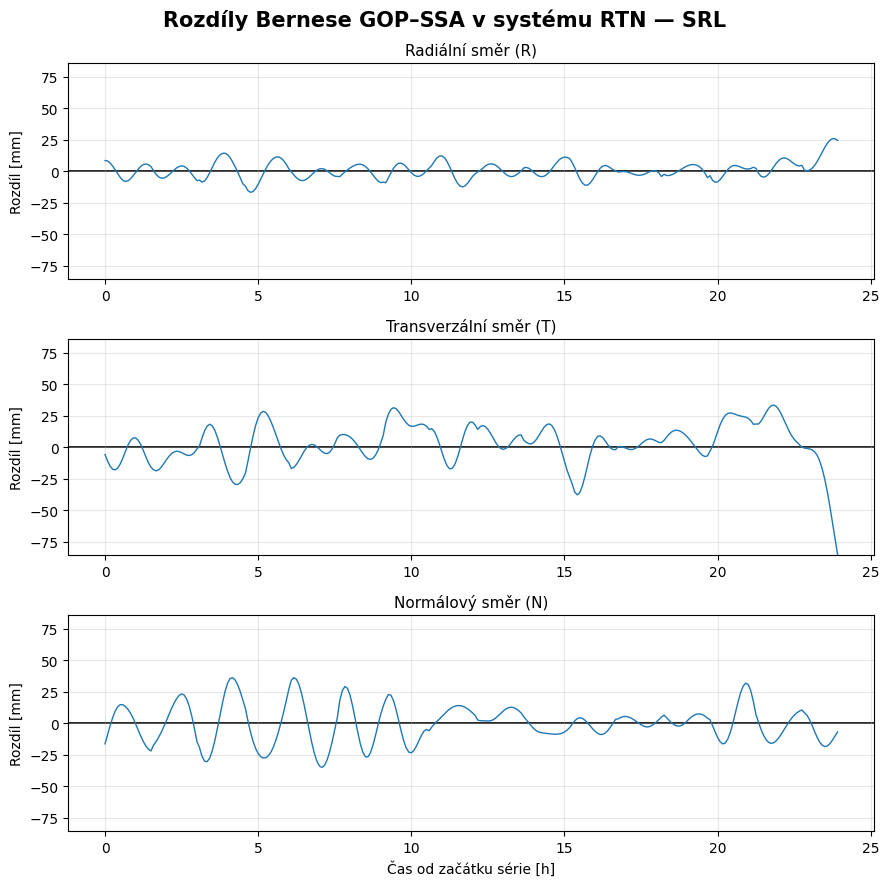

In [13]:
df = clean_df.copy()
t_hours = (df["epoch_datetime"] - df["epoch_datetime"].iloc[0]).dt.total_seconds() / 3600.0

fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True, sharey=True)

components = [
    ("dR", "Radiální směr (R)"),
    ("dT", "Transverzální směr (T)"),
    ("dN", "Normálový směr (N)"),
]

max_abs = np.max(np.abs(df[["dR", "dT", "dN"]].values))
ylim = (-max_abs - 0.5, max_abs + 0.5)

for ax, (col, title) in zip(axes, components):
    ax.plot(t_hours, df[col].values, linewidth=1.0)
    ax.axhline(0, color="black", linewidth=1.2, zorder=0)
    ax.set_ylabel("Rozdíl [mm]")
    ax.set_title(title, fontsize=11)
    ax.set_ylim(ylim)
    ax.tick_params(axis="x", labelbottom=True)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Čas od začátku série [h]")
fig.suptitle(f"Rozdíly Bernese {_sol_display} v systému RTN — {_sat_display}", fontsize=15, fontweight="bold")

plt.tight_layout()
_stem = FIGURES_DIR / f"{_sat_label}_{_sol_label}_{_doy_str}_rtn_differences"
fig.savefig(_stem.with_suffix(".pdf"), bbox_inches="tight")
fig.savefig(_stem.with_suffix(".png"), bbox_inches="tight", dpi=150)
print(f"Uloženo: {_stem}  [.pdf + .png]")
plt.show()


## RTN differences — histogram

Uloženo: C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\images\results\satellites\bernese\sa\sa_ZAZG_doy001_rtn_histogram  [.pdf + .png]


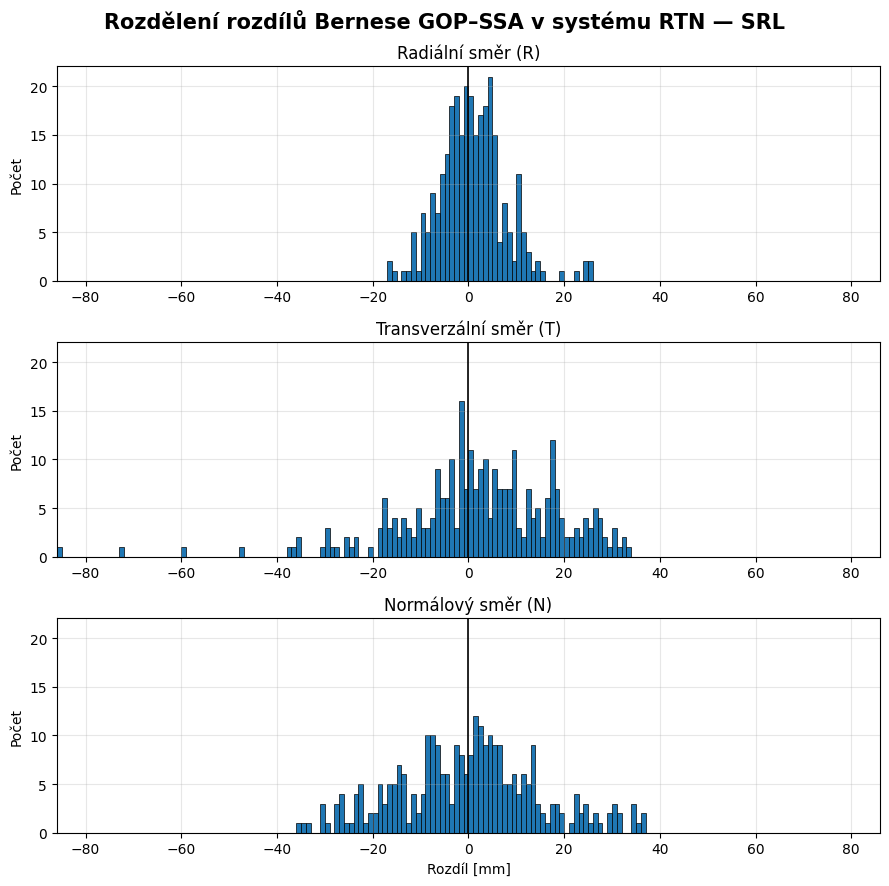

In [14]:
df = clean_df.copy()

fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True, sharey=True)

components = [
    ("dR", "Radiální směr (R)"),
    ("dT", "Transverzální směr (T)"),
    ("dN", "Normálový směr (N)"),
]

max_abs = np.max(np.abs(df[["dR", "dT", "dN"]].values))
xmax = np.ceil(max_abs)
bins = np.arange(-xmax, xmax + 1, 1)

for ax, (col, title) in zip(axes, components):
    ax.hist(df[col].values, bins=bins, edgecolor="black", linewidth=0.5)
    ax.axvline(0, color="black", linewidth=1.2)
    ax.set_ylabel("Počet")
    ax.set_title(title)
    ax.set_xlim(-xmax, xmax)
    ax.tick_params(axis="x", labelbottom=True)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Rozdíl [mm]")
fig.suptitle(f"Rozdělení rozdílů Bernese {_sol_display} v systému RTN — {_sat_display}", fontsize=15, fontweight="bold")

plt.tight_layout()
_stem = FIGURES_DIR / f"{_sat_label}_{_sol_label}_{_doy_str}_rtn_histogram"
fig.savefig(_stem.with_suffix(".pdf"), bbox_inches="tight")
fig.savefig(_stem.with_suffix(".png"), bbox_inches="tight", dpi=150)
print(f"Uloženo: {_stem}  [.pdf + .png]")
plt.show()


## RTN periodogram — Lomb-Scargle

Uloženo: C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\images\results\satellites\bernese\sa\sa_ZAZG_doy001_rtn_periodograms_lomb_scargle  [.pdf + .png]


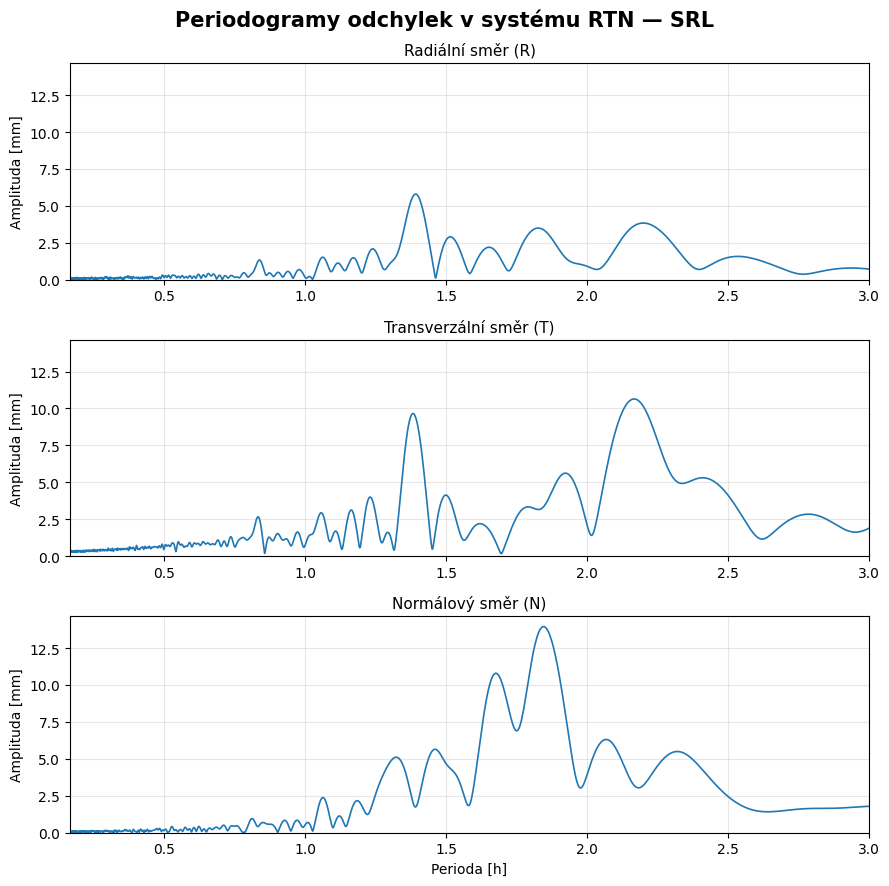

In [15]:
df = clean_df.copy()

t = (df["epoch_datetime"] - df["epoch_datetime"].iloc[0]).dt.total_seconds().values

components = [
    ("dR", "Radiální směr (R)"),
    ("dT", "Transverzální směr (T)"),
    ("dN", "Normálový směr (N)"),
]

MIN_PERIOD_S = 10 * 60    # 10 minut
MAX_PERIOD_S = 3 * 3600   # 3 hodiny

periodograms = {}
global_max = 0

for col, _ in components:
    pgram = compute_periodogram(
        t, df[col].values,
        method="lomb_scargle",
        min_period=MIN_PERIOD_S,
        max_period=MAX_PERIOD_S,
    )
    periodograms[col] = pgram
    local_max = pgram.loc[pgram["period"] / 3600 > 0.5, "amplitude"].max()
    if local_max > global_max:
        global_max = local_max

fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)

for ax, (col, title) in zip(axes, components):
    pgram = periodograms[col]
    periods_h = pgram["period"] / 3600
    ax.plot(periods_h, pgram["amplitude"], linewidth=1.2, zorder=2)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel("Amplituda [mm]")
    ax.set_ylim(0, global_max * 1.05)
    ax.tick_params(axis="x", labelbottom=True)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Perioda [h]")
axes[-1].set_xlim(MIN_PERIOD_S / 3600, MAX_PERIOD_S / 3600)
fig.suptitle(f"Periodogramy odchylek v systému RTN — {_sat_display}", fontsize=15, fontweight="bold")

plt.tight_layout()
_stem = FIGURES_DIR / f"{_sat_label}_{_sol_label}_{_doy_str}_rtn_periodograms_lomb_scargle"
fig.savefig(_stem.with_suffix(".pdf"), bbox_inches="tight")
fig.savefig(_stem.with_suffix(".png"), bbox_inches="tight", dpi=150)
print(f"Uloženo: {_stem}  [.pdf + .png]")
plt.show()


## RTN periodogram — FFT

Uloženo: C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\images\results\satellites\bernese\sa\sa_ZAZG_doy001_rtn_periodograms_fft  [.pdf + .png]


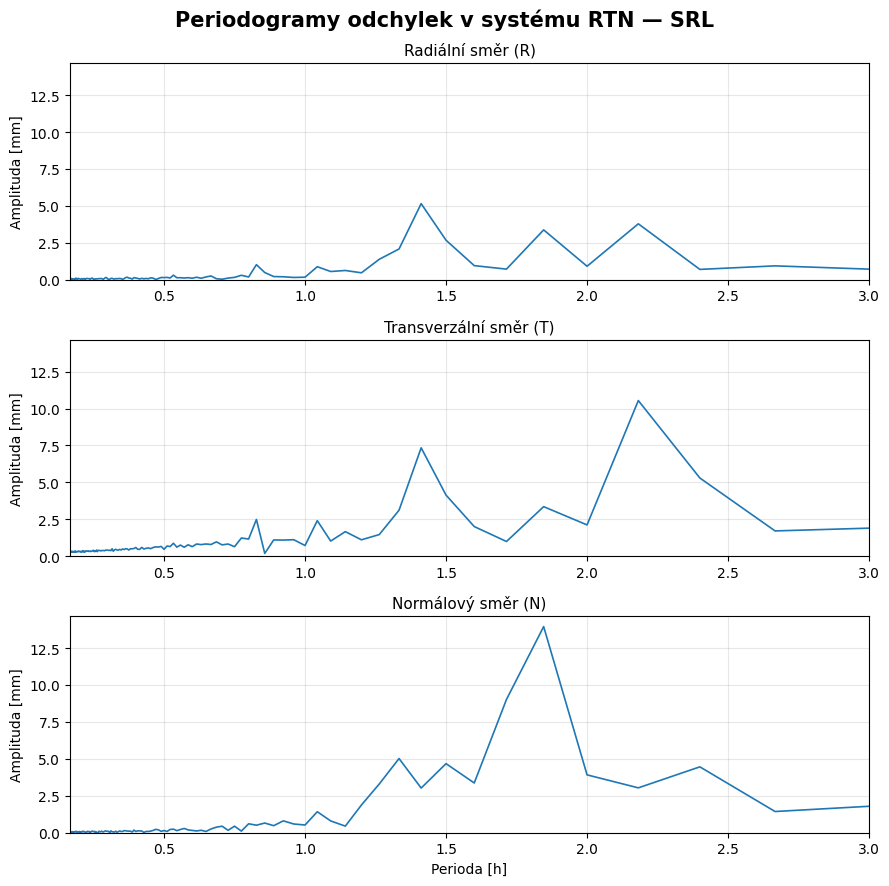

In [16]:
df = clean_df.copy()

t = (df["epoch_datetime"] - df["epoch_datetime"].iloc[0]).dt.total_seconds().values

components = [
    ("dR", "Radiální směr (R)"),
    ("dT", "Transverzální směr (T)"),
    ("dN", "Normálový směr (N)"),
]

MIN_PERIOD_S = 10 * 60    # 10 minut
MAX_PERIOD_S = 3 * 3600   # 3 hodiny

periodograms = {}
global_max = 0

for col, _ in components:
    pgram = compute_periodogram(
        t, df[col].values,
        method="fft",
        min_period=MIN_PERIOD_S,
        max_period=MAX_PERIOD_S,
    )
    periodograms[col] = pgram
    local_max = pgram.loc[pgram["period"] / 3600 > 0.5, "amplitude"].max()
    if local_max > global_max:
        global_max = local_max

fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)

for ax, (col, title) in zip(axes, components):
    pgram = periodograms[col]
    periods_h = pgram["period"] / 3600
    ax.plot(periods_h, pgram["amplitude"], linewidth=1.2, zorder=2)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel("Amplituda [mm]")
    ax.set_ylim(0, global_max * 1.05)
    ax.tick_params(axis="x", labelbottom=True)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Perioda [h]")
axes[-1].set_xlim(MIN_PERIOD_S / 3600, MAX_PERIOD_S / 3600)
fig.suptitle(f"Periodogramy odchylek v systému RTN — {_sat_display}", fontsize=15, fontweight="bold")

plt.tight_layout()
_stem = FIGURES_DIR / f"{_sat_label}_{_sol_label}_{_doy_str}_rtn_periodograms_fft"
fig.savefig(_stem.with_suffix(".pdf"), bbox_inches="tight")
fig.savefig(_stem.with_suffix(".png"), bbox_inches="tight", dpi=150)
print(f"Uloženo: {_stem}  [.pdf + .png]")
plt.show()


## Daily RTN RMS over time

Uloženo: C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\images\results\satellites\bernese\sa\sa_ZAZG_doy001-doy030_daily_rtn_rms  [.pdf + .png]


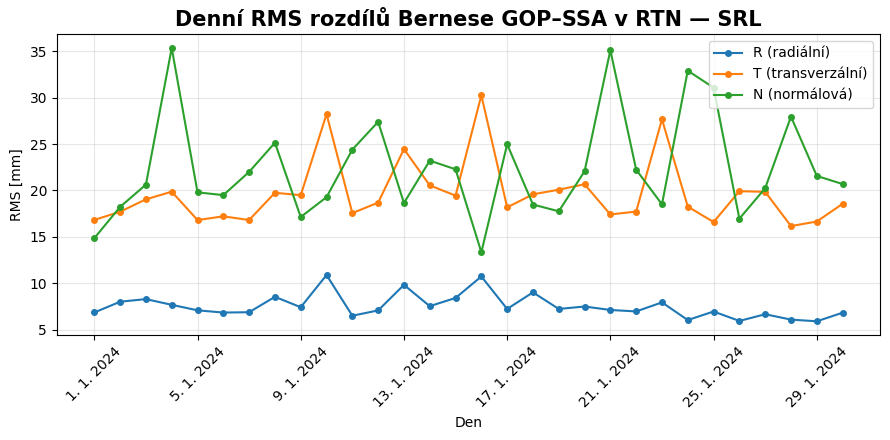

In [17]:
fig, ax = plt.subplots(figsize=(9, 4.5))

ax.plot(plot_df["day"], plot_df["R_rms"] * 1000, "o-", color="C0", linewidth=1.5, markersize=4, label="R (radiální)")
ax.plot(plot_df["day"], plot_df["T_rms"] * 1000, "o-", color="C1", linewidth=1.5, markersize=4, label="T (transverzální)")
ax.plot(plot_df["day"], plot_df["N_rms"] * 1000, "o-", color="C2", linewidth=1.5, markersize=4, label="N (normálová)")

ax.set_xlabel("Den")
ax.set_ylabel("RMS [mm]")
ax.set_title(f"Denní RMS rozdílů Bernese {_sol_display} v RTN — {_sat_display}", fontsize=15, fontweight="bold")
ax.grid(True, alpha=0.3)
ax.legend()

_pd = plot_df["day"].tolist()
_pd_start = min(_pd).timetuple().tm_yday
_pd_end   = max(_pd).timetuple().tm_yday
_pd_str   = f"doy{_pd_start:03d}" if _pd_start == _pd_end else f"doy{_pd_start:03d}-doy{_pd_end:03d}"

ax.xaxis.set_major_formatter(mdates.DateFormatter("%#d. %#m. %Y"))
plt.xticks(rotation=45)
plt.tight_layout()
_stem = FIGURES_DIR / f"{_sat_label}_{_sol_label}_{_pd_str}_daily_rtn_rms"
fig.savefig(_stem.with_suffix(".pdf"), bbox_inches="tight")
fig.savefig(_stem.with_suffix(".png"), bbox_inches="tight", dpi=150)
print(f"Uloženo: {_stem}  [.pdf + .png]")
plt.show()


## Daily 3D RMS over time

Uloženo: C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\images\results\satellites\bernese\sa\sa_ZAZG_doy001-doy030_daily_3d_rms  [.pdf + .png]


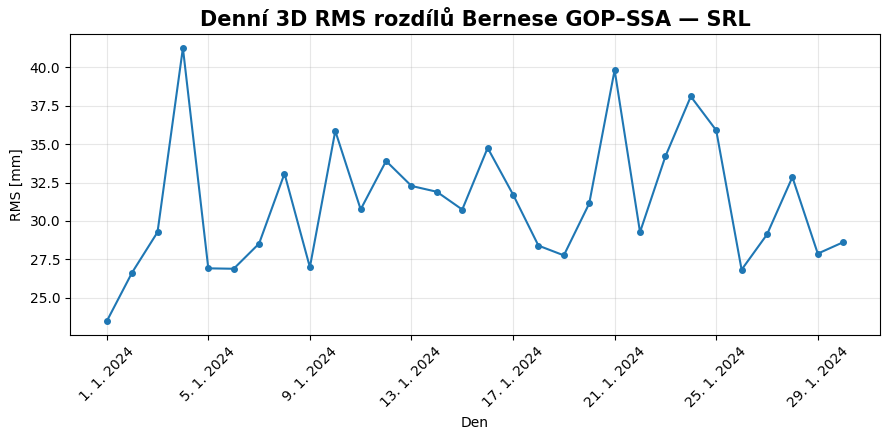

In [18]:
fig, ax = plt.subplots(figsize=(9, 4.5))

ax.plot(plot_df["day"], plot_df["3D_rms"] * 1000, "o-", linewidth=1.5, markersize=4)

ax.set_xlabel("Den")
ax.set_ylabel("RMS [mm]")
ax.set_title(f"Denní 3D RMS rozdílů Bernese {_sol_display} — {_sat_display}", fontsize=15, fontweight="bold")
ax.grid(True, alpha=0.3)

_pd = plot_df["day"].tolist()
_pd_start = min(_pd).timetuple().tm_yday
_pd_end   = max(_pd).timetuple().tm_yday
_pd_str   = f"doy{_pd_start:03d}" if _pd_start == _pd_end else f"doy{_pd_start:03d}-doy{_pd_end:03d}"

ax.xaxis.set_major_formatter(mdates.DateFormatter("%#d. %#m. %Y"))
plt.xticks(rotation=45)
plt.tight_layout()
_stem = FIGURES_DIR / f"{_sat_label}_{_sol_label}_{_pd_str}_daily_3d_rms"
fig.savefig(_stem.with_suffix(".pdf"), bbox_inches="tight")
fig.savefig(_stem.with_suffix(".png"), bbox_inches="tight", dpi=150)
print(f"Uloženo: {_stem}  [.pdf + .png]")
plt.show()


Uloženo: C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\images\results\satellites\bernese\sa\sa_ZAZG_doy001-doy030_daily_rtn_3d_rms  [.pdf + .png]


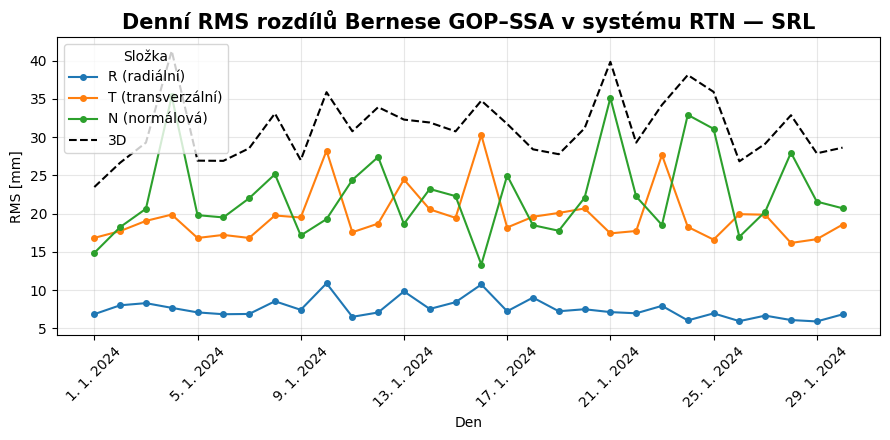

In [19]:
fig, ax = plt.subplots(figsize=(9, 4.5))

ax.plot(plot_df["day"], plot_df["R_rms"] * 1000, "o-", color="C0", linewidth=1.5, markersize=4, label="R (radiální)")
ax.plot(plot_df["day"], plot_df["T_rms"] * 1000, "o-", color="C1", linewidth=1.5, markersize=4, label="T (transverzální)")
ax.plot(plot_df["day"], plot_df["N_rms"] * 1000, "o-", color="C2", linewidth=1.5, markersize=4, label="N (normálová)")
ax.plot(plot_df["day"], plot_df["3D_rms"] * 1000, "k--", linewidth=1.5, markersize=4, label="3D")

ax.set_xlabel("Den")
ax.set_ylabel("RMS [mm]")
ax.set_title(f"Denní RMS rozdílů Bernese {_sol_display} v systému RTN — {_sat_display}", fontsize=15, fontweight="bold")
ax.grid(True, alpha=0.3)
ax.legend(title="Složka")

_pd = plot_df["day"].tolist()
_pd_start = min(_pd).timetuple().tm_yday
_pd_end   = max(_pd).timetuple().tm_yday
_pd_str   = f"doy{_pd_start:03d}" if _pd_start == _pd_end else f"doy{_pd_start:03d}-doy{_pd_end:03d}"

ax.xaxis.set_major_formatter(mdates.DateFormatter("%#d. %#m. %Y"))
plt.xticks(rotation=45)
plt.tight_layout()
_stem = FIGURES_DIR / f"{_sat_label}_{_sol_label}_{_pd_str}_daily_rtn_3d_rms"
fig.savefig(_stem.with_suffix(".pdf"), bbox_inches="tight")
fig.savefig(_stem.with_suffix(".png"), bbox_inches="tight", dpi=150)
print(f"Uloženo: {_stem}  [.pdf + .png]")
plt.show()

## Daily RTN mean differences

Uloženo: C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\images\results\satellites\bernese\sa\sa_ZAZG_doy001-doy030_daily_rtn_mean  [.pdf + .png]


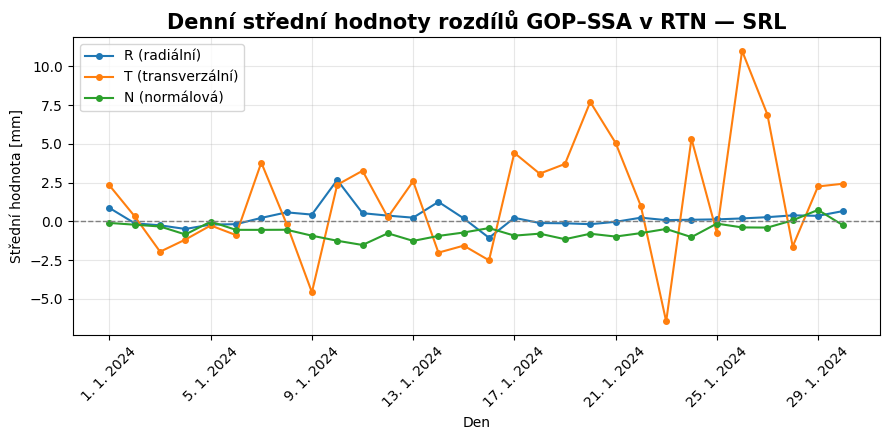

In [20]:
fig, ax = plt.subplots(figsize=(9, 4.5))

ax.plot(plot_df["day"], plot_df["R_mean"] * 1000, "o-", color="C0", linewidth=1.5, markersize=4, label="R (radiální)")
ax.plot(plot_df["day"], plot_df["T_mean"] * 1000, "o-", color="C1", linewidth=1.5, markersize=4, label="T (transverzální)")
ax.plot(plot_df["day"], plot_df["N_mean"] * 1000, "o-", color="C2", linewidth=1.5, markersize=4, label="N (normálová)")

ax.axhline(0.0, color="gray", linewidth=1.0, linestyle="--")
ax.set_xlabel("Den")
ax.set_ylabel("Střední hodnota [mm]")
ax.set_title(f"Denní střední hodnoty rozdílů {_sol_display} v RTN — {_sat_display}", fontsize=15, fontweight="bold")
ax.grid(True, alpha=0.3)
ax.legend()

_pd = plot_df["day"].tolist()
_pd_start = min(_pd).timetuple().tm_yday
_pd_end   = max(_pd).timetuple().tm_yday
_pd_str   = f"doy{_pd_start:03d}" if _pd_start == _pd_end else f"doy{_pd_start:03d}-doy{_pd_end:03d}"

ax.xaxis.set_major_formatter(mdates.DateFormatter("%#d. %#m. %Y"))
plt.xticks(rotation=45)
plt.tight_layout()
_stem = FIGURES_DIR / f"{_sat_label}_{_sol_label}_{_pd_str}_daily_rtn_mean"
fig.savefig(_stem.with_suffix(".pdf"), bbox_inches="tight")
fig.savefig(_stem.with_suffix(".png"), bbox_inches="tight", dpi=150)
print(f"Uloženo: {_stem}  [.pdf + .png]")
plt.show()

## Daily RMS vs RMS0

Uloženo: C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\images\results\satellites\bernese\sa\sa_ZAZG_doy001-doy030_daily_3d_rms_vs_rms0  [.pdf + .png]


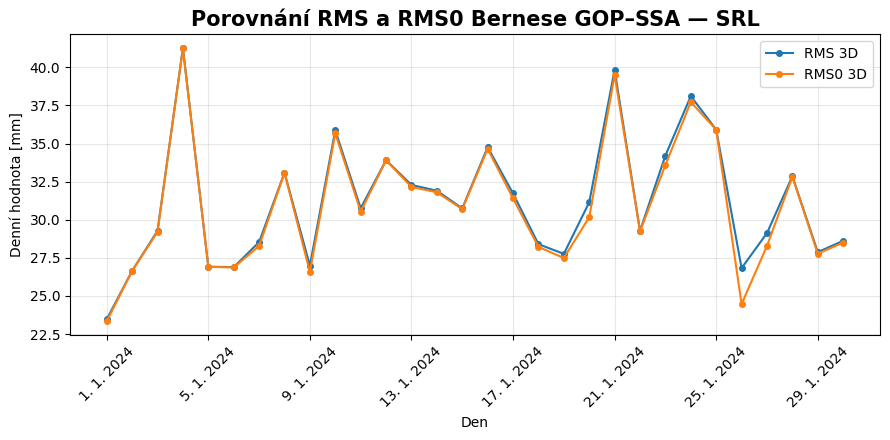

In [21]:
fig, ax = plt.subplots(figsize=(9, 4.5))

ax.plot(plot_df["day"], plot_df["3D_rms"]  * 1000, "o-", linewidth=1.5, markersize=4, label="RMS 3D")
ax.plot(plot_df["day"], plot_df["3D_rms0"] * 1000, "o-", linewidth=1.5, markersize=4, label="RMS0 3D")

ax.set_xlabel("Den")
ax.set_ylabel("Denní hodnota [mm]")
ax.set_title(f"Porovnání RMS a RMS0 Bernese {_sol_display} — {_sat_display}", fontsize=15, fontweight="bold")
ax.grid(True, alpha=0.3)
ax.legend()

_pd = plot_df["day"].tolist()
_pd_start = min(_pd).timetuple().tm_yday
_pd_end   = max(_pd).timetuple().tm_yday
_pd_str   = f"doy{_pd_start:03d}" if _pd_start == _pd_end else f"doy{_pd_start:03d}-doy{_pd_end:03d}"

ax.xaxis.set_major_formatter(mdates.DateFormatter("%#d. %#m. %Y"))
plt.xticks(rotation=45)
plt.tight_layout()
_stem = FIGURES_DIR / f"{_sat_label}_{_sol_label}_{_pd_str}_daily_3d_rms_vs_rms0"
fig.savefig(_stem.with_suffix(".pdf"), bbox_inches="tight")
fig.savefig(_stem.with_suffix(".png"), bbox_inches="tight", dpi=150)
print(f"Uloženo: {_stem}  [.pdf + .png]")
plt.show()


## Statistics for the selected test day

In [22]:
def _rms_col(s): return float((s**2).mean()**0.5)
def _std_col(s): return float(((s - s.mean())**2).mean()**0.5)

day_table = pd.DataFrame({
    "component": ["R", "T", "N", "3D"],
    "mean_mm":   [clean_df["dR"].mean(),     clean_df["dT"].mean(),
                  clean_df["dN"].mean(),     clean_df["d3D"].mean()],
    "std_mm":    [_std_col(clean_df["dR"]),  _std_col(clean_df["dT"]),
                  _std_col(clean_df["dN"]),  _std_col(clean_df["d3D"])],
    "rms_mm":    [_rms_col(clean_df["dR"]),  _rms_col(clean_df["dT"]),
                  _rms_col(clean_df["dN"]),  _rms_col(clean_df["d3D"])],
})
display(day_table.round(2))

,component,mean_mm,std_mm,rms_mm
0,R,0.86000,6.80000,6.85000
1,T,2.32000,16.66000,16.82000
2,N,-0.10000,14.86000,14.86000
3,3D,20.09000,12.13000,23.47000


In [23]:
_day_cols = [
    Col("component", "Složka",                    None),
    Col("mean_mm",   "Střední hodnota [mm]", 2),
    Col("std_mm",    "Směrodatná odchylka [mm]", 2),
    Col("rms_mm",    "RMS [mm]",                        2),
]
_table_path = TABLES_DIR / f"{_sat_label}_{_sol_label}_{_doy_str}_day_stats.tex"
save_latex_table(
    day_table, _table_path, cols=_day_cols,
    caption=f"Statistiky rozdílů {_sol_display} v RTN pro den {_doy_str} — {_sat_display}",
    label=f"tab:{_sat_label}_{_sol_label}_{_doy_str}_day_stats",
    print_preview=True,
)
print(f"Uloženo: {_table_path}")

\begin{table}[H]
\centering
\caption{Statistiky rozdílů GOP–SSA v RTN pro den doy001 — SRL}
\label{tab:sa_ZAZG_doy001_day_stats}
\begin{tabular}{lrrr}
\toprule
Složka & Střední hodnota [mm] & Směrodatná odchylka [mm] & RMS [mm] \\
\midrule
R & 0.86 & 6.80 & 6.85 \\
T & 2.32 & 16.66 & 16.82 \\
N & -0.10 & 14.86 & 14.86 \\
3D & 20.09 & 12.13 & 23.47 \\
\bottomrule
\end{tabular}
\end{table}

Uloženo: C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\tables\satellites\bernese\sa\sa_ZAZG_doy001_day_stats.tex


## RMS summary for the full period

In [24]:
_pd = plot_df["day"].tolist()
_pd_start = min(_pd).timetuple().tm_yday
_pd_end   = max(_pd).timetuple().tm_yday
_pd_str   = f"doy{_pd_start:03d}" if _pd_start == _pd_end else f"doy{_pd_start:03d}-doy{_pd_end:03d}"

rms_table = pd.DataFrame({
    "component": ["R", "T", "N", "3D"],
    "min_mm":    [plot_df["R_rms"].min()  * 1000, plot_df["T_rms"].min()  * 1000,
                  plot_df["N_rms"].min()  * 1000, plot_df["3D_rms"].min() * 1000],
    "mean_mm":   [plot_df["R_rms"].mean() * 1000, plot_df["T_rms"].mean() * 1000,
                  plot_df["N_rms"].mean() * 1000, plot_df["3D_rms"].mean()* 1000],
    "max_mm":    [plot_df["R_rms"].max()  * 1000, plot_df["T_rms"].max()  * 1000,
                  plot_df["N_rms"].max()  * 1000, plot_df["3D_rms"].max() * 1000],
})
display(rms_table.round(2))

,component,min_mm,mean_mm,max_mm
0,R,5.90000,7.53000,10.88000
1,T,16.16000,19.67000,30.25000
2,N,13.34000,22.39000,35.35000
3,3D,23.47000,31.16000,41.27000


In [25]:
_rms_cols = [
    Col("component", "Složka",          None),
    Col("min_mm",    "Min. RMS [mm]",   2),
    Col("mean_mm",   "Prům. RMS [mm]", 2),
    Col("max_mm",    "Max. RMS [mm]",   2),
]
_table_path = TABLES_DIR / f"{_sat_label}_{_sol_label}_{_pd_str}_rms.tex"
save_latex_table(
    rms_table, _table_path, cols=_rms_cols,
    caption=f"Denní RMS rozdílů {_sol_display} v RTN ({_pd_str}) — {_sat_display}",
    label=f"tab:{_sat_label}_{_sol_label}_{_pd_str}_rms",
    print_preview=True,
)
print(f"Uloženo: {_table_path}")

\begin{table}[H]
\centering
\caption{Denní RMS rozdílů GOP–SSA v RTN (doy001-doy030) — SRL}
\label{tab:sa_ZAZG_doy001-doy030_rms}
\begin{tabular}{lrrr}
\toprule
Složka & Min. RMS [mm] & Prům. RMS [mm] & Max. RMS [mm] \\
\midrule
R & 5.90 & 7.53 & 10.88 \\
T & 16.16 & 19.67 & 30.25 \\
N & 13.34 & 22.39 & 35.35 \\
3D & 23.47 & 31.16 & 41.27 \\
\bottomrule
\end{tabular}
\end{table}

Uloženo: C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\tables\satellites\bernese\sa\sa_ZAZG_doy001-doy030_rms.tex
